<div style="background-color: #f8f9fa; padding: 25px; border-radius: 10px; border-left: 6px solid #1a365d; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
    <h1 style="color: #1a365d; margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Data Science Assignment 4</h1>
    <h3 style="color: #4a5568; margin-top: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">University of Tehran - Spring 2026</h3>
    <hr style="border: 1px solid #e2e8f0;">
    <p style="font-size: 16px; color: #2d3748;">
        <b>Course:</b> Data Science <br><br>
        <b>🧑‍💻 Implementer:</b> Parsa Saeednia <br>
        <b>🆔 Student ID:</b> 810102460 <br><br>
        <h5 style="color: #1a365d;"> TASK 3 Implementation</h5>
    </p>
</div>

<div class="alert alert-info" style="border-left: 4px solid #3182ce; background-color: #ebf8ff; color: #2b6cb0;">
    <strong>💡 Project Overview:</strong> 
    This notebook contains the programmatic implementation for Assignment 4 - Task 3. It tackles <b>Knowledge Tracing</b> using the ASSISTments2017 dataset. We model sequential student learning behaviors over time using <b>Recurrent Neural Networks (RNN)</b> and <b>LSTMs</b> to predict whether a student will answer the next question correctly.
</div>

##

## Table of Contents
1. [Data Exploration & Temporal Analysis](#exploration)
2. [Sequence Preprocessing & Padding](#preprocessing)
3. [RNN Architecture & Training](#modeling)
4. [Evaluation & LSTM Comparison](#evaluation)

<a id="exploration"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">1. Data Exploration & Temporal Analysis</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> We analyze chronological student interactions to understand correctness patterns, skill difficulties, and correlations between help-seeking behaviors (hints, time taken) and future success.
</div>

##

### 1.1 Importing Analytical Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

### 1.2 Loading & Inspecting the Dataset

In [7]:
df = pd.read_csv('data/assistments2017.csv')

display(df.info())
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 85132 entries, 0 to 85131
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   studentId               85132 non-null  int64  
 1   skill                   85132 non-null  str    
 2   problemType             85132 non-null  str    
 3   startTime               85132 non-null  str    
 4   timeTaken               85132 non-null  float64
 5   correct                 85132 non-null  int64  
 6   hintCount               85132 non-null  int64  
 7   attemptCount            85132 non-null  int64  
 8   frPast5WrongCount       85132 non-null  int64  
 9   responseIsFillIn        85132 non-null  int64  
 10  responseIsChosen        85132 non-null  int64  
 11  consecutiveErrorsInRow  85132 non-null  int64  
dtypes: float64(1), int64(8), str(3)
memory usage: 7.8 MB


None

,studentId,skill,problemType,startTime,timeTaken,correct,hintCount,attemptCount,frPast5WrongCount,responseIsFillIn,responseIsChosen,consecutiveErrorsInRow
0,8,perimeter,textfieldquestion,2005-05-09 13:55:03,67.0,0,1,1,0,0,0,0
1,8,perimeter,textfieldquestion,2005-05-09 13:56:10,5.0,0,2,2,0,0,0,0
2,8,perimeter,textfieldquestion,2005-05-09 13:56:15,14.0,1,2,3,0,0,0,0
3,8,area,radioquestion,2005-05-09 13:56:29,17.0,1,0,1,1,0,0,0
4,8,area,textfieldquestion,2005-05-09 13:56:46,13.0,0,1,1,1,0,0,0


### 1.3 Sequence Length Distribution

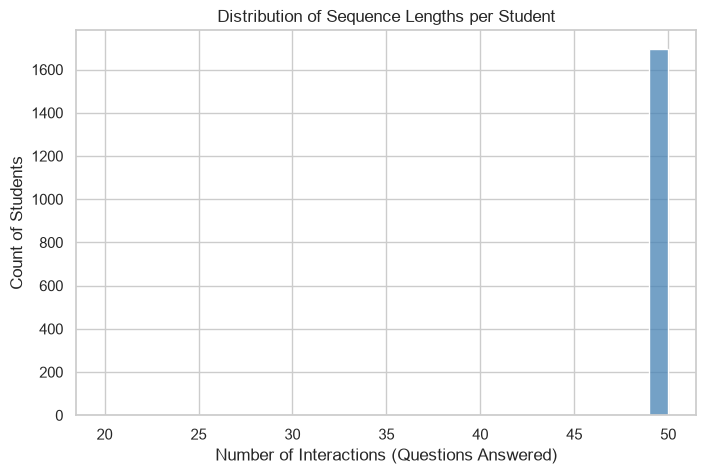

count    1705.000000
mean       49.930792
std         1.174313
min        20.000000
25%        50.000000
50%        50.000000
75%        50.000000
max        50.000000
dtype: float64

In [8]:
sequence_lengths = df.groupby('studentId').size()

plt.figure(figsize=(8, 5))
sns.histplot(sequence_lengths, bins=30, color='steelblue')
plt.title('Distribution of Sequence Lengths per Student')
plt.xlabel('Number of Interactions (Questions Answered)')
plt.ylabel('Count of Students')
plt.show()

display(sequence_lengths.describe())

### 1.4 Global Correctness Imbalance

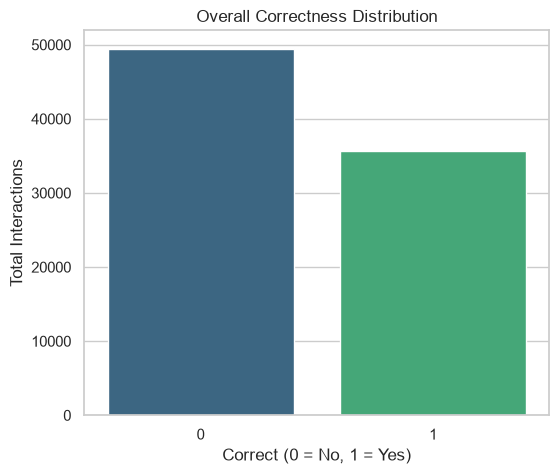

correct
0    58.117981
1    41.882019
Name: proportion, dtype: float64

In [9]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='correct', hue='correct', palette='viridis', legend=False)
plt.title('Overall Correctness Distribution')
plt.xlabel('Correct (0 = No, 1 = Yes)')
plt.ylabel('Total Interactions')
plt.show()

display(df['correct'].value_counts(normalize=True) * 100)

### 1.5 Student Ability vs. Help-Seeking Behaviors

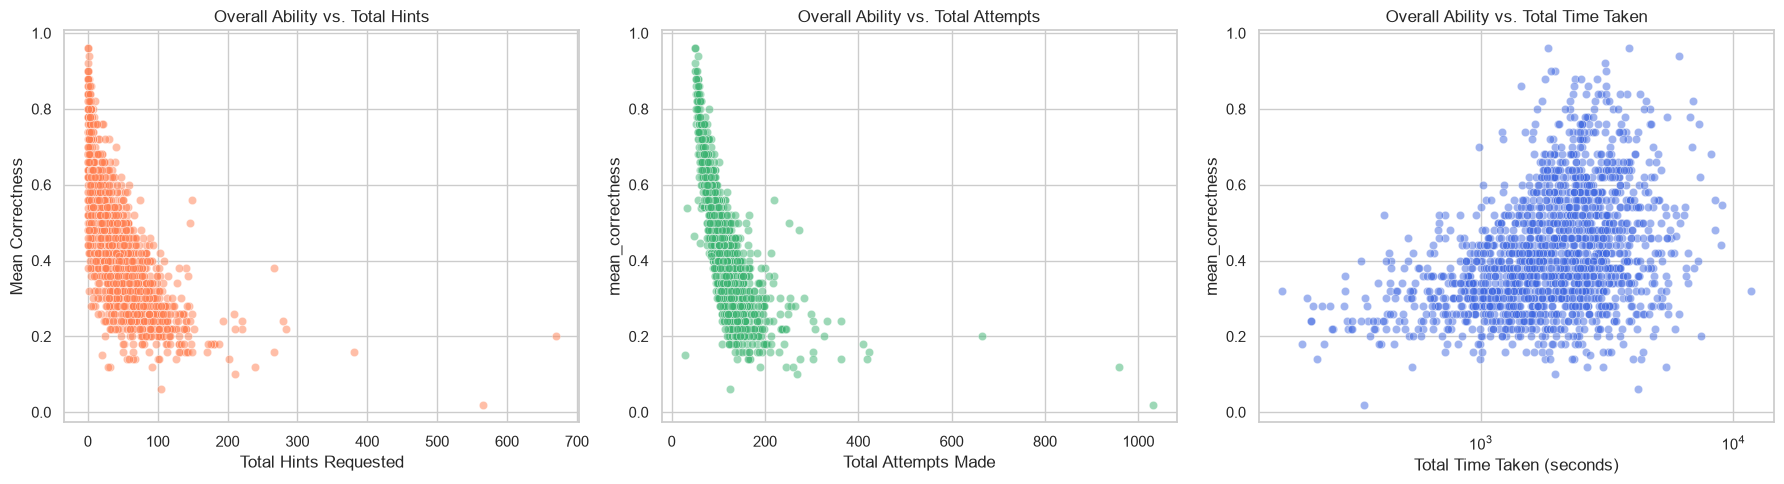

In [11]:
student_ability = df.groupby('studentId').agg(
    mean_correctness=('correct', 'mean'),
    total_time=('timeTaken', 'sum'),
    total_hints=('hintCount', 'sum'),
    total_attempts=('attemptCount', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=student_ability, x='total_hints', y='mean_correctness', ax=axes[0], alpha=0.5, color='coral')
axes[0].set_title('Overall Ability vs. Total Hints')
axes[0].set_xlabel('Total Hints Requested')
axes[0].set_ylabel('Mean Correctness')

sns.scatterplot(data=student_ability, x='total_attempts', y='mean_correctness', ax=axes[1], alpha=0.5, color='mediumseagreen')
axes[1].set_title('Overall Ability vs. Total Attempts')
axes[1].set_xlabel('Total Attempts Made')

sns.scatterplot(data=student_ability, x='total_time', y='mean_correctness', ax=axes[2], alpha=0.5, color='royalblue')
axes[2].set_title('Overall Ability vs. Total Time Taken')
axes[2].set_xlabel('Total Time Taken (seconds)')
axes[2].set_xscale('log')

plt.tight_layout()
plt.show()

### 1.6 Correlation Analysis: Past Struggles vs. Future Performance

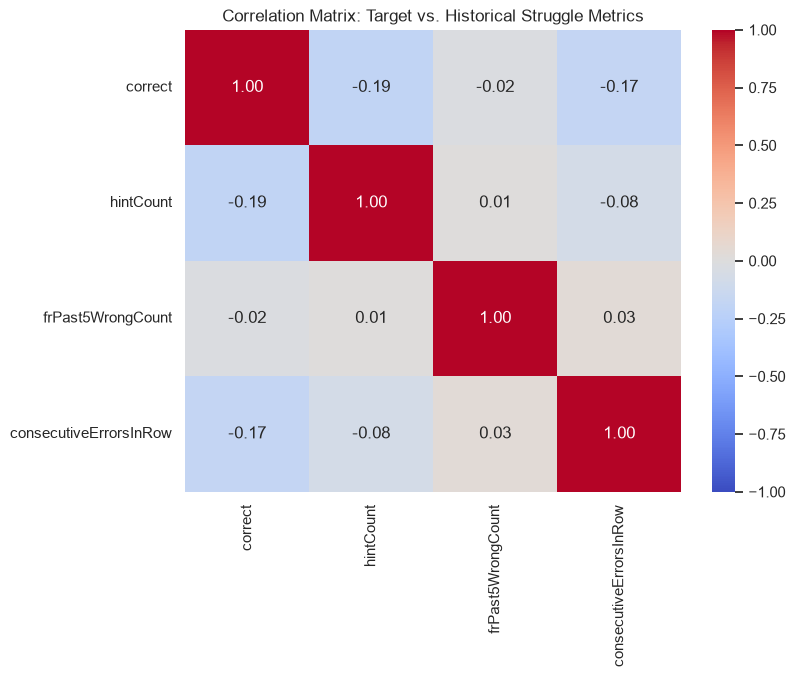

In [12]:
focus_features = ['correct', 'hintCount', 'frPast5WrongCount', 'consecutiveErrorsInRow']
corr_matrix = df[focus_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix: Target vs. Historical Struggle Metrics')
plt.show()

### 1.7 Visualizing Correctness by Skill & Problem Type

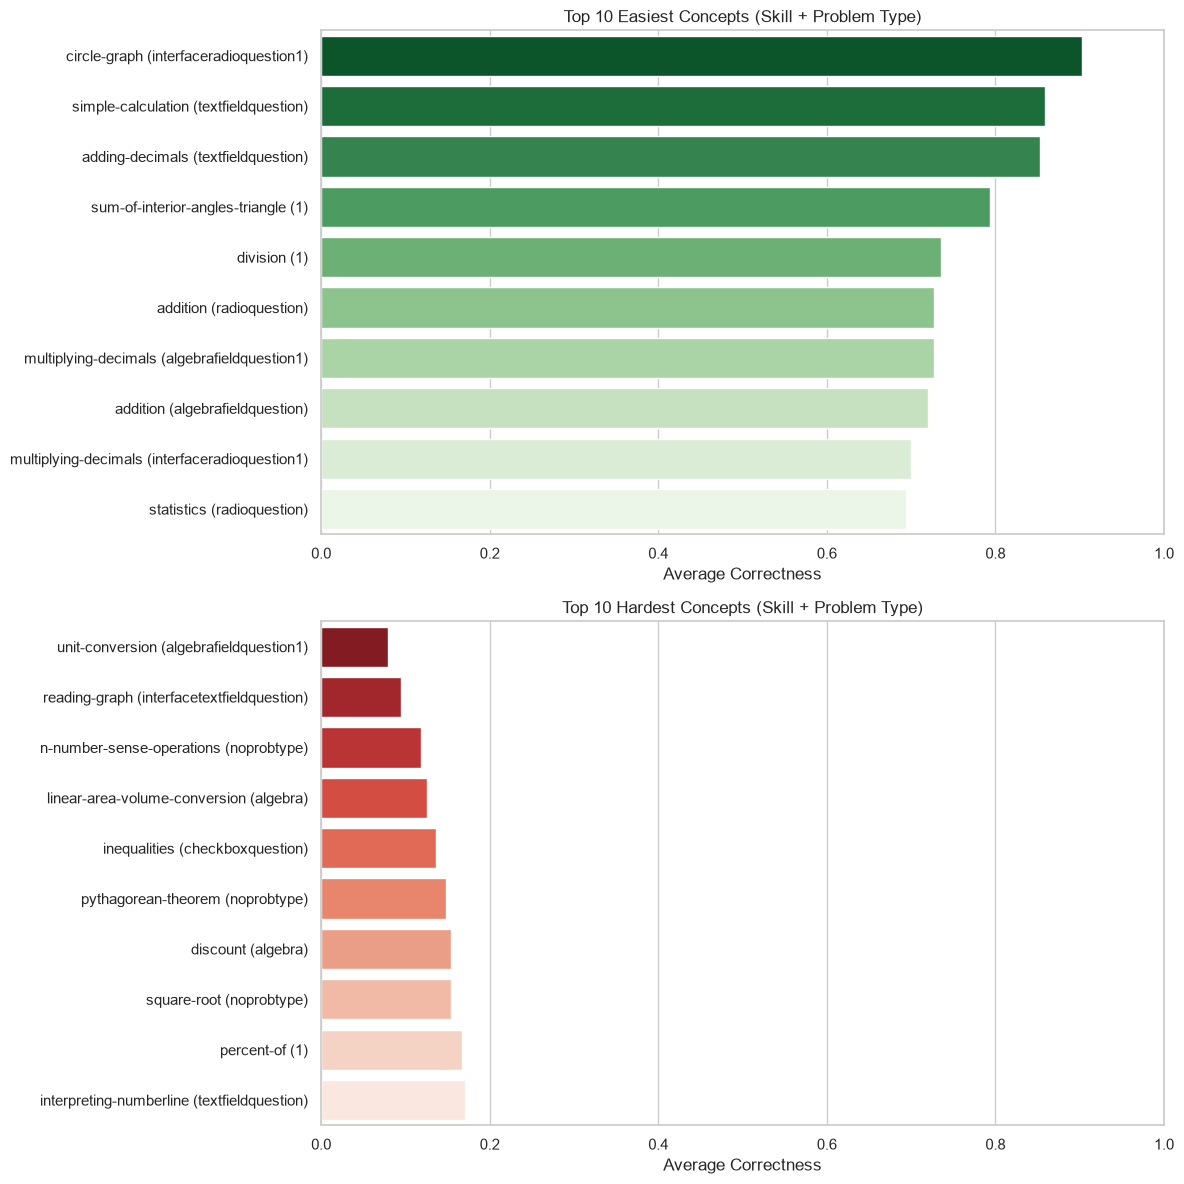

In [13]:
df['skill_problem'] = df['skill'] + " (" + df['problemType'] + ")"

combo_stats = df.groupby('skill_problem').agg(
    total_attempts=('correct', 'count'),
    avg_correct=('correct', 'mean')
).reset_index()

combo_stats = combo_stats[combo_stats['total_attempts'] > 30]

top_10_easiest = combo_stats.nlargest(10, 'avg_correct')
top_10_hardest = combo_stats.nsmallest(10, 'avg_correct')

fig, axes = plt.subplots(2, 1, figsize=(12, 12))

sns.barplot(data=top_10_easiest, x='avg_correct', y='skill_problem', ax=axes[0], palette='Greens_r', hue='skill_problem', legend=False)
axes[0].set_title('Top 10 Easiest Concepts (Skill + Problem Type)')
axes[0].set_xlabel('Average Correctness')
axes[0].set_ylabel('')
axes[0].set_xlim(0, 1)

sns.barplot(data=top_10_hardest, x='avg_correct', y='skill_problem', ax=axes[1], palette='Reds_r', hue='skill_problem', legend=False)
axes[1].set_title('Top 10 Hardest Concepts (Skill + Problem Type)')
axes[1].set_xlabel('Average Correctness')
axes[1].set_ylabel('')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

### 1.8 The Forgetting Curve: Analyzing Time Lags Between Interactions

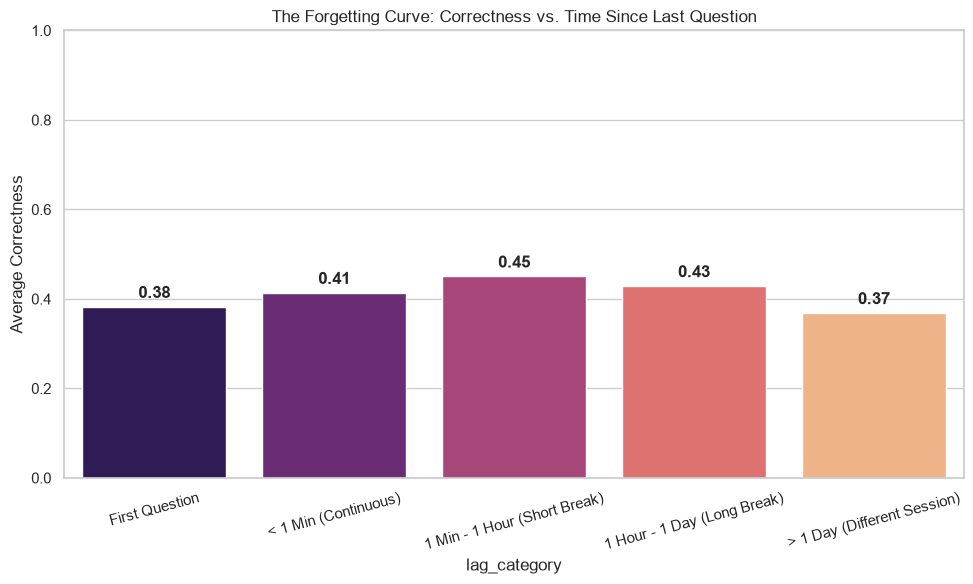

In [15]:
df['startTime'] = pd.to_datetime(df['startTime'])
df = df.sort_values(by=['studentId', 'startTime'])

df['time_lag_seconds'] = df.groupby('studentId')['startTime'].diff().dt.total_seconds()
df['time_lag_seconds'] = df['time_lag_seconds'].fillna(0)

def categorize_lag(seconds):
    if seconds == 0: return 'First Question'
    elif seconds < 60: return '< 1 Min (Continuous)'
    elif seconds < 3600: return '1 Min - 1 Hour (Short Break)'
    elif seconds < 86400: return '1 Hour - 1 Day (Long Break)'
    else: return '> 1 Day (Different Session)'

df['lag_category'] = df['time_lag_seconds'].apply(categorize_lag)

lag_stats = df.groupby('lag_category')['correct'].mean().reindex([
    'First Question', '< 1 Min (Continuous)', '1 Min - 1 Hour (Short Break)',
    '1 Hour - 1 Day (Long Break)', '> 1 Day (Different Session)'
])

plt.figure(figsize=(10, 6))
sns.barplot(x=lag_stats.index, y=lag_stats.values, palette='magma', hue=lag_stats.index, legend=False)
plt.title('The Forgetting Curve: Correctness vs. Time Since Last Question')
plt.ylabel('Average Correctness')
plt.ylim(0, 1)
plt.xticks(rotation=15)

for i, v in enumerate(lag_stats.values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 1.9 Temporal Dynamics: First 10 vs. Last 10 Interactions

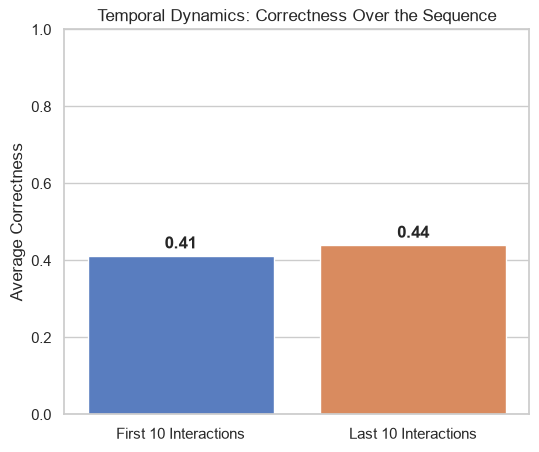

In [16]:
df['interaction_num'] = df.groupby('studentId').cumcount() + 1

first_10 = df[df['interaction_num'] <= 10]['correct'].mean()
last_10 = df[(df['interaction_num'] > 40) & (df['interaction_num'] <= 50)]['correct'].mean()

plt.figure(figsize=(6, 5))
sns.barplot(x=['First 10 Interactions', 'Last 10 Interactions'], y=[first_10, last_10], palette='muted', hue=['First 10 Interactions', 'Last 10 Interactions'], legend=False)
plt.title('Temporal Dynamics: Correctness Over the Sequence')
plt.ylabel('Average Correctness')
plt.ylim(0, 1)

for i, v in enumerate([first_10, last_10]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()

### 1.10 Analysis of Question Formats: Fill-in vs. Multiple Choice

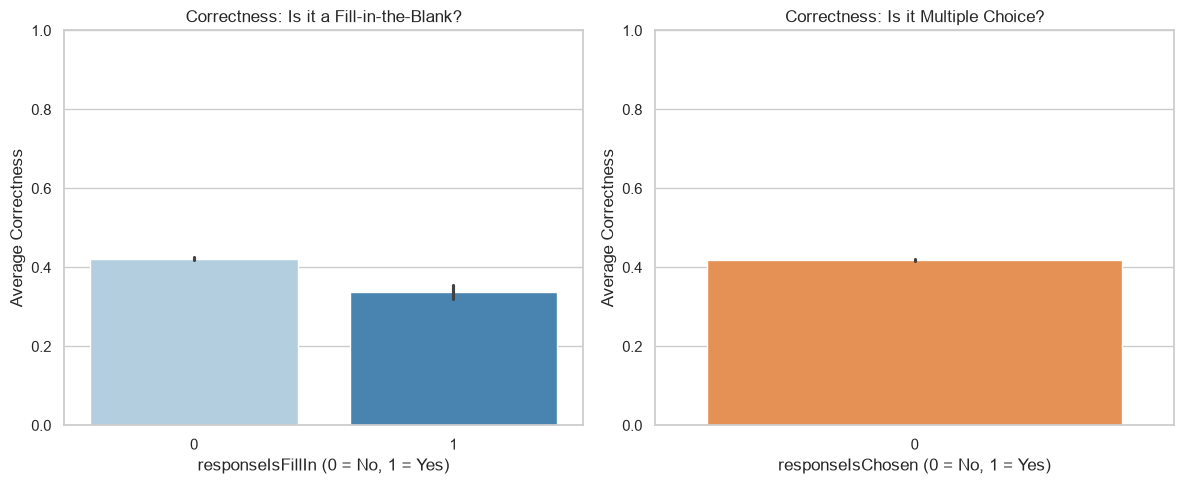

,"Fill-In (1=Yes, 0=No)","Chosen (1=Yes, 0=No)"
0,0.421646,0.41882
1,0.338189,NaN


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, x='responseIsFillIn', y='correct', ax=axes[0], palette='Blues', hue='responseIsFillIn', legend=False)
axes[0].set_title('Correctness: Is it a Fill-in-the-Blank?')
axes[0].set_xlabel('responseIsFillIn (0 = No, 1 = Yes)')
axes[0].set_ylabel('Average Correctness')
axes[0].set_ylim(0, 1)

sns.barplot(data=df, x='responseIsChosen', y='correct', ax=axes[1], palette='Oranges', hue='responseIsChosen', legend=False)
axes[1].set_title('Correctness: Is it Multiple Choice?')
axes[1].set_xlabel('responseIsChosen (0 = No, 1 = Yes)')
axes[1].set_ylabel('Average Correctness')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

display(pd.DataFrame({
    'Fill-In (1=Yes, 0=No)': df.groupby('responseIsFillIn')['correct'].mean(),
    'Chosen (1=Yes, 0=No)': df.groupby('responseIsChosen')['correct'].mean()
}))

### 1.11 Final Sanity Checks: Multicollinearity & Rare Skills

In [22]:
print("MULTICOLLINEARITY CHECK :")
features_to_check = ['hintCount', 'attemptCount', 'consecutiveErrorsInRow', 'timeTaken', 'time_lag_seconds']
display(df[features_to_check].corr().round(2))

print("\nRARE SKILLS CHECK :\n")
df['skill_problem'] = df['skill'] + "_" + df['problemType']
skill_counts = df['skill_problem'].value_counts()

total_skills = len(skill_counts)
rare_skills_under_10 = len(skill_counts[skill_counts < 10])
rare_skills_under_5 = len(skill_counts[skill_counts < 5])

print(f"Total Unique Skill-Problem Combos: {total_skills}")
print(f"Combos appearing fewer than 10 times: {rare_skills_under_10} ({(rare_skills_under_10/total_skills)*100:.1f}%)")
print(f"Combos appearing fewer than 5 times: {rare_skills_under_5} ({(rare_skills_under_5/total_skills)*100:.1f}%)")

print("\nBottom 5 Rarest Combos:")
print(skill_counts.tail(5))

MULTICOLLINEARITY CHECK :


,hintCount,attemptCount,consecutiveErrorsInRow,timeTaken,time_lag_seconds
hintCount,1.00,0.72,-0.08,-0.10,-0.04
attemptCount,0.72,1.00,0.27,-0.10,-0.05
consecutiveErrorsInRow,-0.08,0.27,1.00,-0.00,0.00
timeTaken,-0.10,-0.10,-0.00,1.00,0.09
time_lag_seconds,-0.04,-0.05,0.00,0.09,1.00



RARE SKILLS CHECK :

Total Unique Skill-Problem Combos: 418
Combos appearing fewer than 10 times: 40 (9.6%)
Combos appearing fewer than 5 times: 17 (4.1%)

Bottom 5 Rarest Combos:
skill_problem
p-patterns-relations-algebra_algebra    1
comparing-fractions_other               1
fraction-multiplication_other           1
multiplying-decimals_algebra            1
square-root_algebrafieldquestion        1
Name: count, dtype: int64


<a id="preprocessing"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">2. Sequence Preprocessing & Padding</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> We apply the findings from our EDA: pruning rare skills, encoding categorical variables (protecting the 0-index for padding), and normalizing continuous features before building PyTorch tensors.
</div>

##

### Label Encoding & Sequence Windowing

### Tensor Formatting & Padding Implementation

<a id="modeling"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">3. RNN Architecture & Training</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> We map the input sequence vectors to hidden states to predict binary performance outcomes. The model is trained using Binary Cross-Entropy loss while monitoring Validation AUC.
</div>

##

### Defining the Recurrent Network

### Training & Validation Loss Monitoring

<a id="evaluation"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">4. Evaluation & LSTM Comparison</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> We evaluate the baseline RNN using Accuracy, Precision, Recall, and AUC. Finally, we replace vanilla RNN layers with Long Short-Term Memory (LSTM) cells to assess improvements in capturing long-term dependencies.
</div>

##

### RNN Evaluation & Confusion Matrix

### LSTM Implementation & Comparative Analysis